In [1]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
from scipy.io import wavfile


## **1. Creación de la señal**

$$x[n] = s_{1}[n] + s_{2}[n]$$


In [8]:
fs = 1000  # Hz
T = 2      # segundos
t = np.arange(0, T, 1/fs)

# Señal limpia
f1 = 10  # Hz
s1 = np.sin(2*np.pi*f1*t)

f2 = 40
s2 = np.sin(2*np.pi*f2*t)

x = s1 + s2


### **1.2 Gráficas**

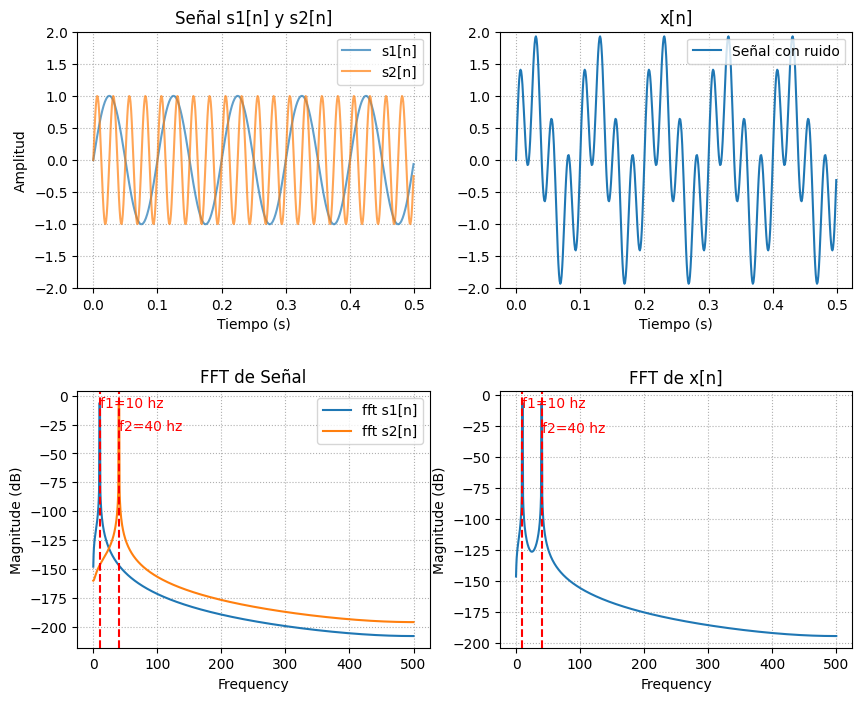

In [14]:
# @title Visualización
# Visualización
plt.figure(figsize=(10,8))
plt.subplots_adjust(hspace=0.4)

plt.subplot(2,2,1)
plt.title("Señal s1[n] y s2[n]")
plt.plot(t[:500], s1[:500], alpha=0.7, label="s1[n]")
plt.plot(t[:500], s2[:500], alpha=0.7, label="s2[n]")
plt.grid(ls=":")
plt.ylim(-2,2)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()

plt.subplot(2,2,3)
plt.title("FFT de Señal")
plt.magnitude_spectrum(s1,Fs=fs, scale="dB", label="fft s1[n]")
plt.magnitude_spectrum(s2,Fs=fs, scale="dB", label="fft s2[n]")
plt.grid(ls=":")
plt.axvline(f1, linestyle="--", color="r")
plt.text(f1, -10, f"f1={f1} hz", color="r", size=10)
plt.axvline(f2, linestyle="--", color="r")
plt.text(f2, -30, f"f2={f2} hz", color="r", size=10)
plt.legend()

plt.subplot(2,2,2)
plt.plot(t[:500], x[:500], label="Señal con ruido")
plt.grid(ls=":")
plt.legend()
plt.ylim(-2,2)
plt.xlabel("Tiempo (s)")
plt.title("x[n]")

plt.subplot(2,2,4)
plt.title("FFT de x[n]")
plt.magnitude_spectrum(x,Fs=fs, scale="dB")
plt.grid(ls=":")
plt.axvline(f1, linestyle="--", color="r")
plt.text(f1, -10, f"f1={f1} hz", color="r", size=10)
plt.axvline(f2, linestyle="--", color="r")
plt.text(f2, -30, f"f2={f2} hz", color="r", size=10)

plt.show()

### **1.2 Exportar a wav**

In [15]:
x_normalized = np.int16(x / np.max(np.abs(x)) * 32767)

wavfile.write("senal4_10_100hz.wav", fs, x_normalized)